<a href="https://colab.research.google.com/github/Adyypower/Deep-learning-Models-or-topics/blob/main/ResNEt50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import  tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50 , preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

In [3]:
IMAGE_SIZE = (100,100)
epochs = 16
batch_size = 128

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
 98% 3.43G/3.50G [01:10<00:02, 27.9MB/s]
100% 3.50G/3.50G [01:10<00:00, 53.5MB/s]


In [7]:
!unzip fruits.zip

Streaming output truncated to the last 5000 lines.
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_277.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_281.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_285.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_289.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_29.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_33.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_37.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_41.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_45.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Tomato 1/r0_49.j

In [10]:
train_path = "/content/fruits-360_100x100/fruits-360/Training"
valid_path = "/content/fruits-360_100x100/fruits-360/Test"

In [9]:
!ls {train_path}

'Apple 10'		     'Cherry Wax not ripen 2'  'Peach 1'
'Apple 11'		     'Cherry Wax Red 1'        'Peach 2'
'Apple 12'		     'Cherry Wax Red 2'        'Peach Flat 1'
'Apple 13'		     'Cherry Wax Red 3'        'Pear 1'
'Apple 14'		     'Cherry Wax Yellow 1'     'Pear 2'
'Apple 17'		     'Chestnut 1'	       'Pear 3'
'Apple 18'		     'Clementine 1'	       'Pear Abate 1'
'Apple 19'		     'Cocos 1'		       'Pear Forelle 1'
'Apple 5'		     'Corn 1'		       'Pear Kaiser 1'
'Apple 6'		     'Corn Husk 1'	       'Pear Monster 1'
'Apple 7'		     'Cucumber 1'	       'Pear Red 1'
'Apple 8'		     'Cucumber 10'	       'Pear Stone 1'
'Apple 9'		     'Cucumber 11'	       'Pear Williams 1'
'Apple Braeburn 1'	     'Cucumber 3'	       'Pepino 1'
'Apple Core 1'		     'Cucumber 4'	       'Pepper Green 1'
'Apple Crimson Snow 1'	     'Cucumber 5'	       'Pepper Orange 1'
'Apple Golden 1'	     'Cucumber 7'	       'Pepper Red 1'
'Apple Golden 2'	     'Cucumber 9'	       'Pepper Yellow 1'
'Apple Golden 3'	     'Cu

In [11]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size = IMAGE_SIZE,
    batch_size = batch_size
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_path,
    image_size = IMAGE_SIZE,
    batch_size = batch_size
)


Found 105221 files belonging to 208 classes.
Found 35119 files belonging to 208 classes.


In [12]:
class_name = train_ds.class_names
k = len(class_name)
print(class_name)

['Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 5', 'Apple 6', 'Apple 7', 'Apple 8', 'Apple 9', 'Apple Braeburn 1', 'Apple Core 1', 'Apple Crimson Snow 1', 'Apple Golden 1', 'Apple Golden 2', 'Apple Golden 3', 'Apple Granny Smith 1', 'Apple Pink Lady 1', 'Apple Red 1', 'Apple Red 2', 'Apple Red 3', 'Apple Red Delicious 1', 'Apple Red Yellow 1', 'Apple Red Yellow 2', 'Apple Rotten 1', 'Apple hit 1', 'Apple worm 1', 'Apricot 1', 'Avocado 1', 'Avocado Black 1', 'Avocado Green 1', 'Avocado ripe 1', 'Banana 1', 'Banana 3', 'Banana 4', 'Banana Lady Finger 1', 'Banana Red 1', 'Beans 1', 'Beetroot 1', 'Blackberrie 1', 'Blackberrie 2', 'Blackberrie half rippen 1', 'Blackberrie not rippen 1', 'Blueberry 1', 'Cabbage red 1', 'Cabbage white 1', 'Cactus fruit 1', 'Cactus fruit green 1', 'Cactus fruit red 1', 'Caju seed 1', 'Cantaloupe 1', 'Cantaloupe 2', 'Carambula 1', 'Carrot 1', 'Cauliflower 1', 'Cherimoya 1', 'Cherry 1', 'Cherry 2', 'Cherry

In [14]:
k

208

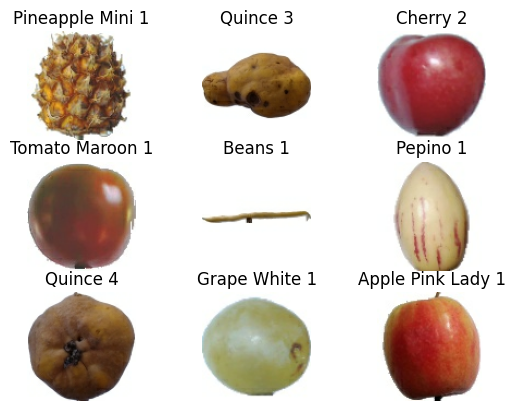

In [15]:
for images , labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_name[labels[i]])
    plt.axis("off")

In [16]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds_unshuffle = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])


In [20]:
ptm = ResNet50(input_shape = (100,100,3),include_top = False,weights = "imagenet")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
for layer in ptm.layers :
  layer.trainable = False

In [25]:
i = Input(shape = (100,100,3))
x = data_augmentation(i)
x = preprocess_input(x)
x = ptm(x)
x = Flatten()(x)
x = Dense(512,activation = "relu")(x)
x = Dropout(0.2)(x)
x = Dense(k,activation = "softmax")(x)
model = Model(i,x)

In [26]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 100, 100,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 100, 100)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 100, 100)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 100, 100)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 100, 100,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 100,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32768)     │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │ 16,777,728 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 208)       │    106,704 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,472,144 (154.39 MB)

 Trainable params: 16,884,432 (64.41 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
model.compile(optimizer = "adam",loss = "sparse_categorical_crossentropy",metrics = ["accuracy"])

In [ ]:
r = model.fit(train_ds,epochs = epochs,validation_data = valid_ds)

Epoch 1/16


In [1]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get the true labels from the validation dataset
true_labels = np.concatenate([y for x, y in valid_ds], axis=0)

# Get the predicted labels
predictions = model.predict(valid_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'valid_ds' is not defined